In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [8]:
df = pd.read_csv("../data/alzheimers_disease_data.csv")
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [9]:
print(df.columns)

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [11]:
cols = df.columns
for col in cols:
    if (df[col].dtype =='object'):
        print(col)
    

DoctorInCharge


In [12]:
if 'DoctorInCharge' in df.columns:
    df = df.drop(columns=['DoctorInCharge'])
    print('removed DoctorInCharge')
else:
    print('DoctorInCharge not present, skipping drop')

removed DoctorInCharge


In [13]:
if 'Ethnicity' in df.columns:
    df = df.drop(columns=['Ethnicity'])
    print('removed Ethnicity')
else:
    print('Ethnicity not present, skipping drop')

removed Ethnicity


In [14]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')

In [15]:
df['Diagnosis'].unique()

array([0, 1])

In [16]:
df.describe()

,PatientID,Age,Gender,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,7.051081,0.252210,0.144253,0.150768,0.200558,0.092601,0.148906,134.264774,89.847836,225.197519,124.335944,59.463533,228.281496,14.755132,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,1.763573,0.434382,0.351428,0.357906,0.400511,0.289940,0.356079,25.949352,17.592496,42.542233,43.366584,23.139174,101.986721,8.613151,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,4.002629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000,150.093316,50.230707,20.003434,50.407194,0.005312,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,5.482997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,112.000000,74.000000,190.252963,87.195798,39.095698,137.583222,7.167602,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,7.115646,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,134.000000,91.000000,225.086430,123.342593,59.768237,230.301983,14.441660,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,8.562521,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,157.000000,105.000000,262.031657,161.733733,78.939050,314.839046,22.161028,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,9.999840,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,299.993352,199.965665,99.980324,399.941862,29.991381,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
print(df.shape)
print(df.size)

(2149, 33)
70917


In [18]:
df.isnull().sum()

PatientID                    0
Age                          0
Gender                       0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfulness                0
Diagnosi

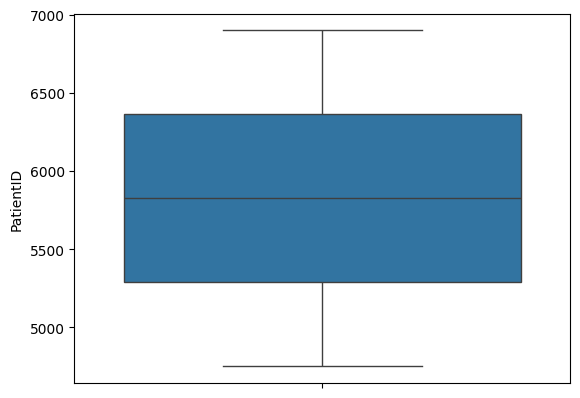

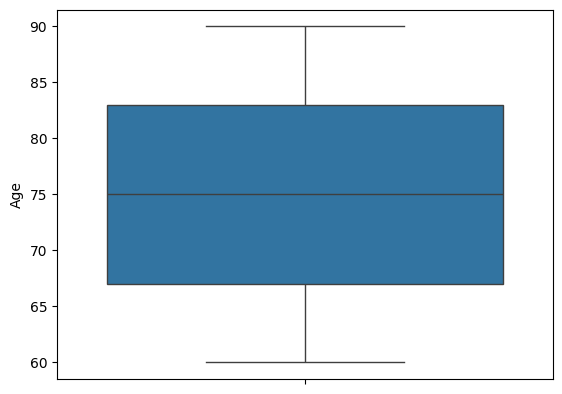

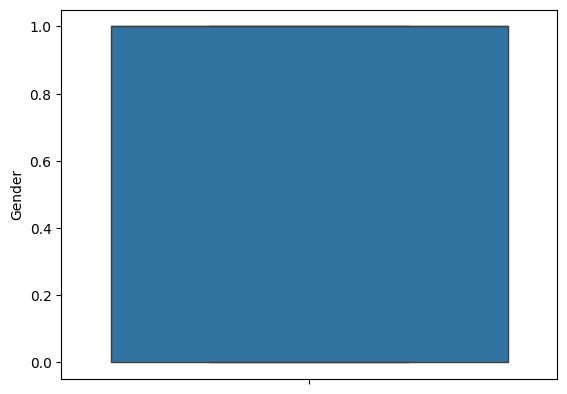

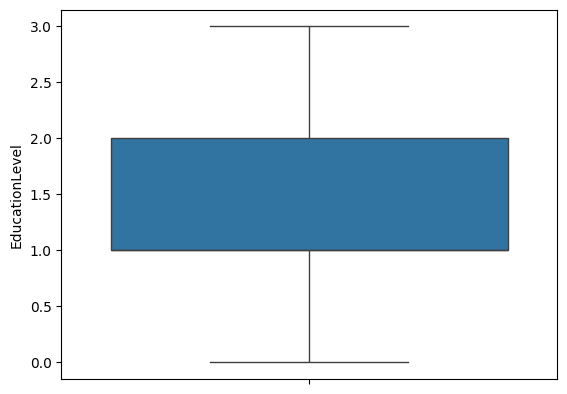

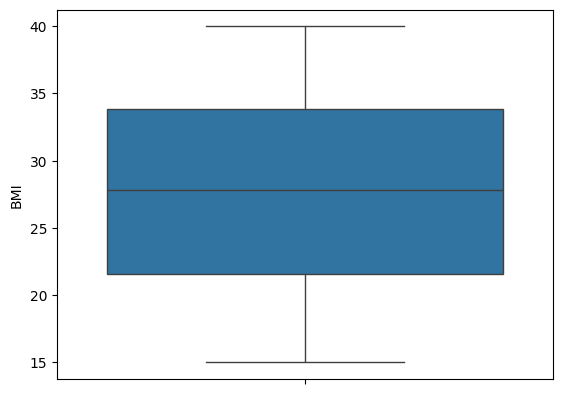

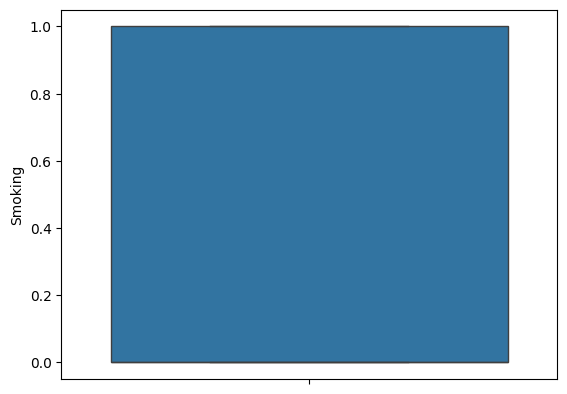

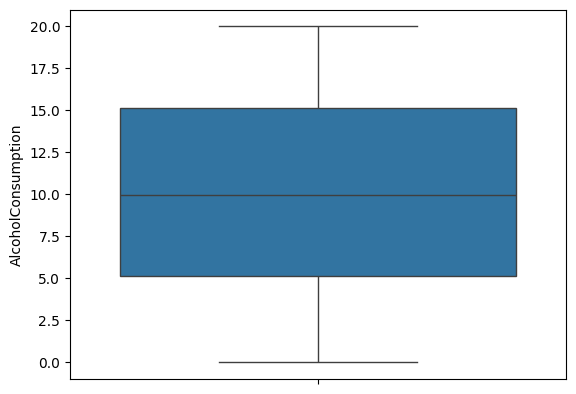

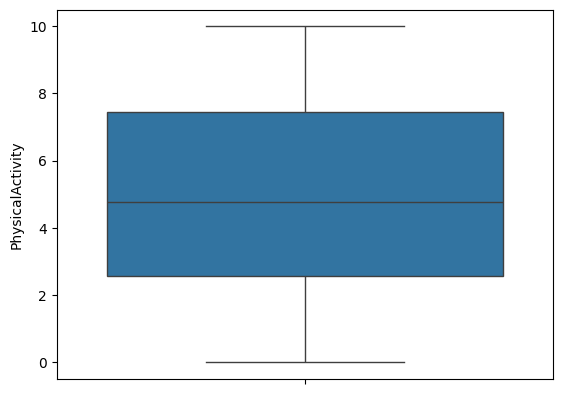

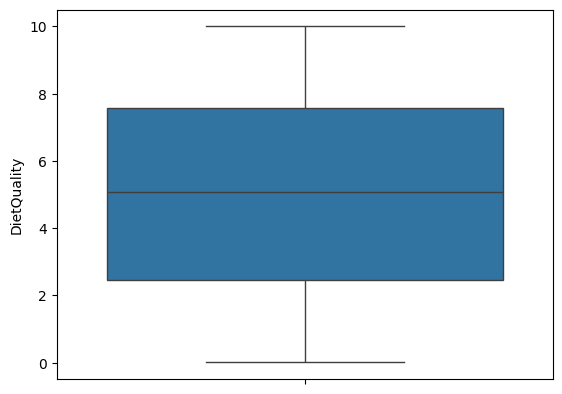

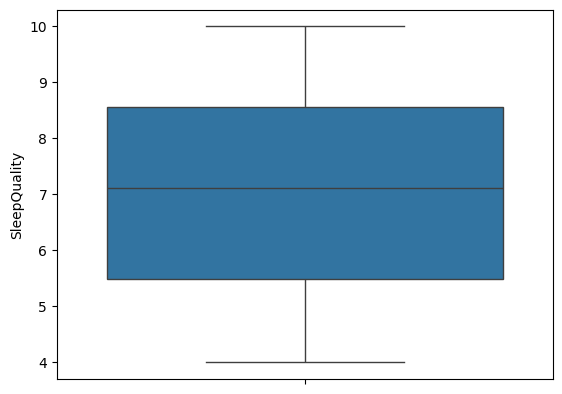

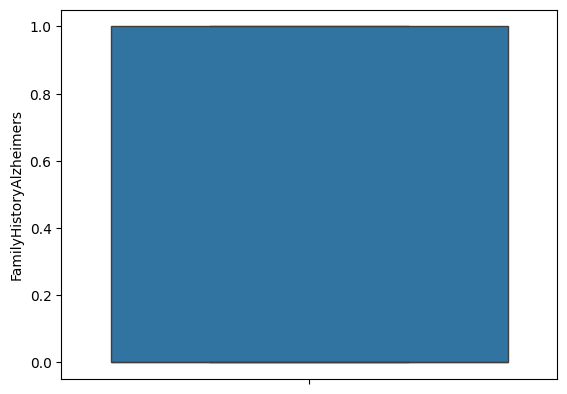

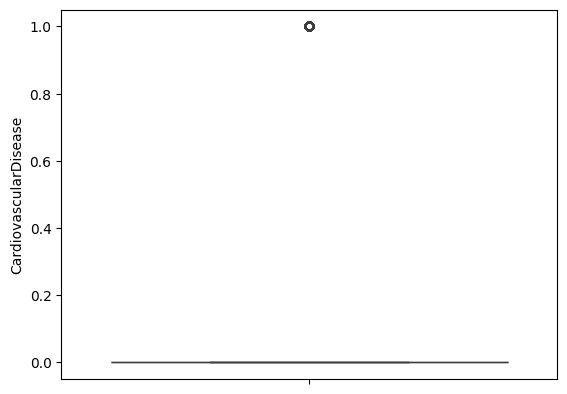

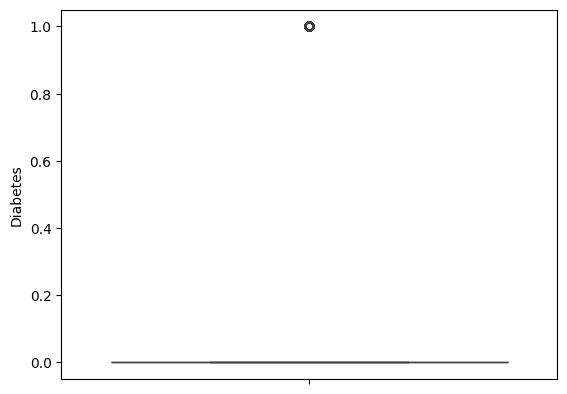

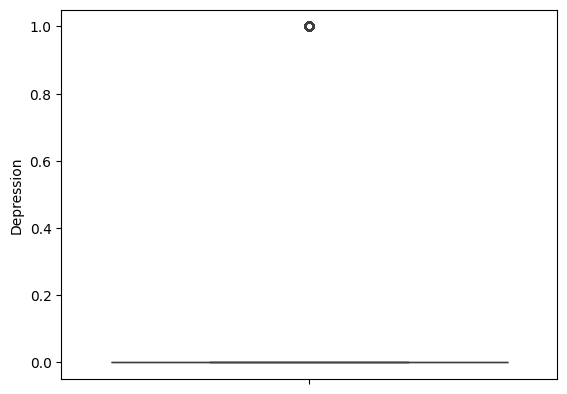

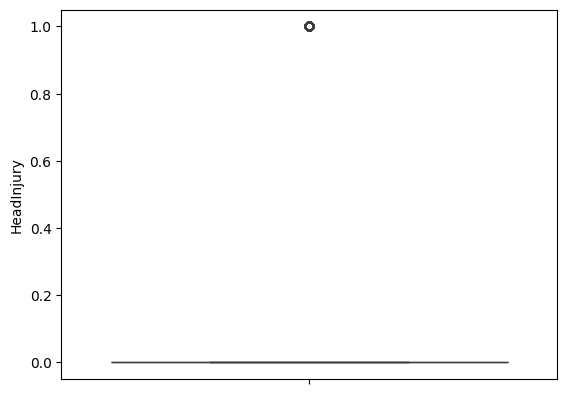

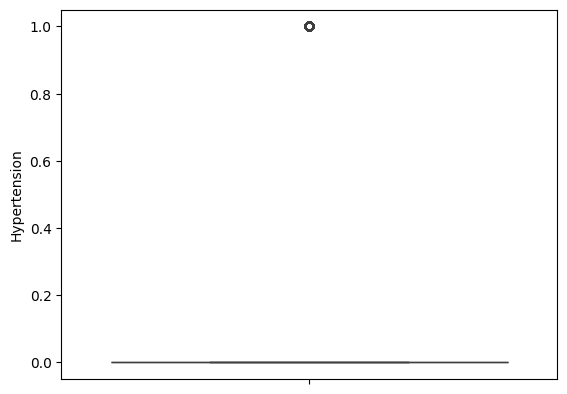

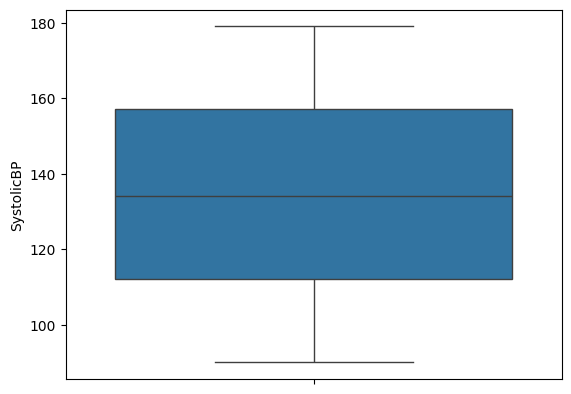

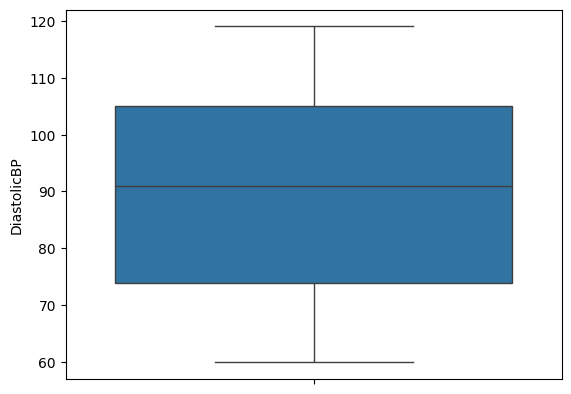

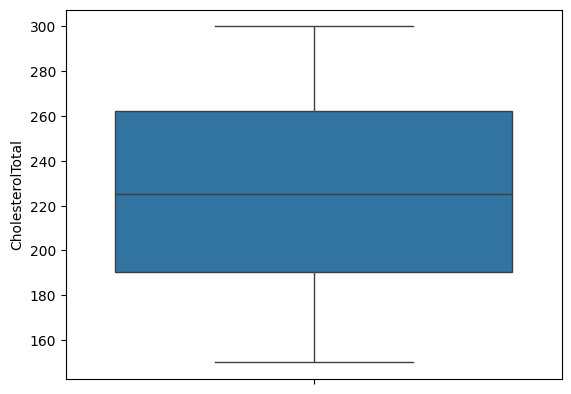

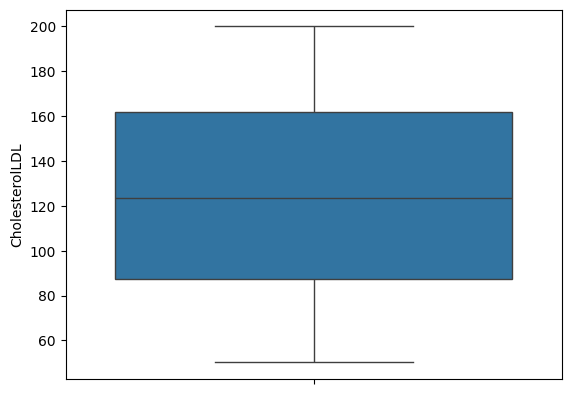

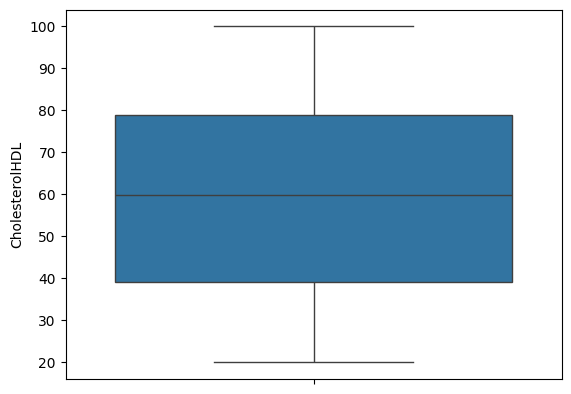

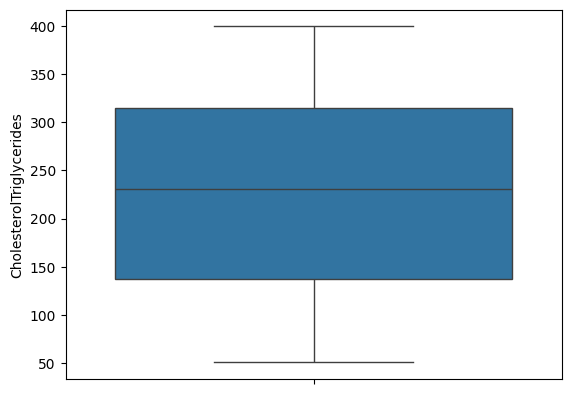

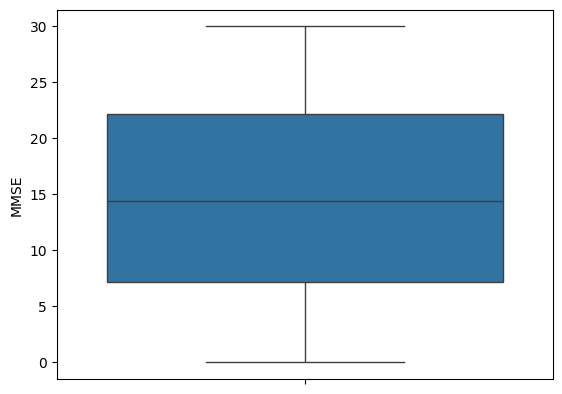

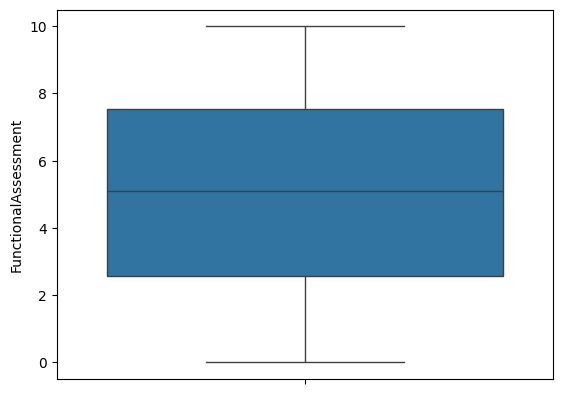

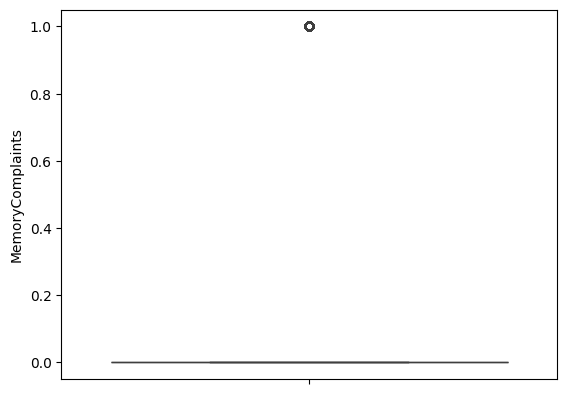

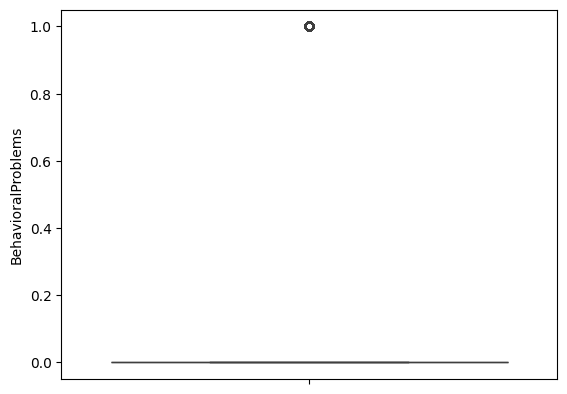

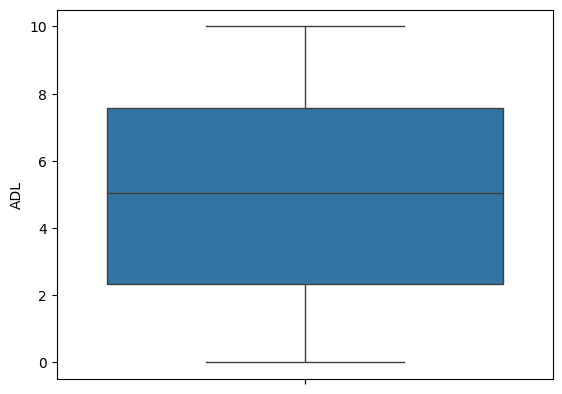

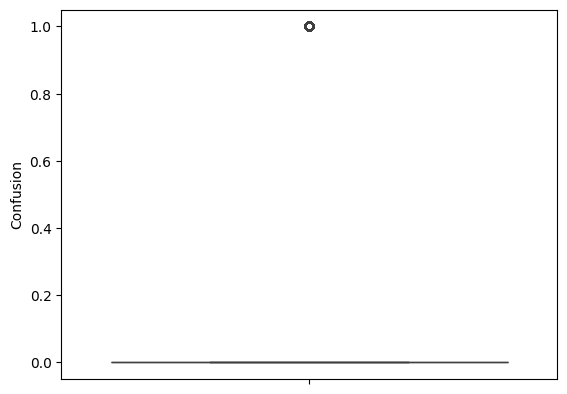

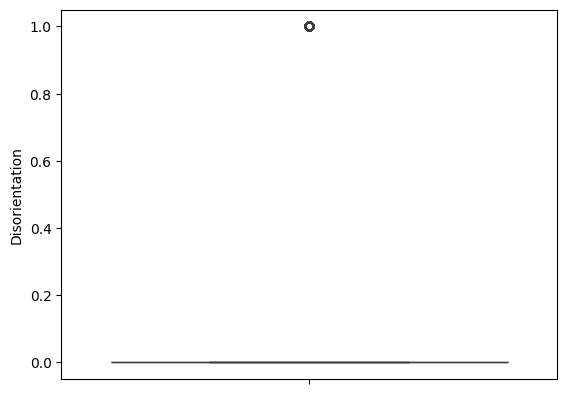

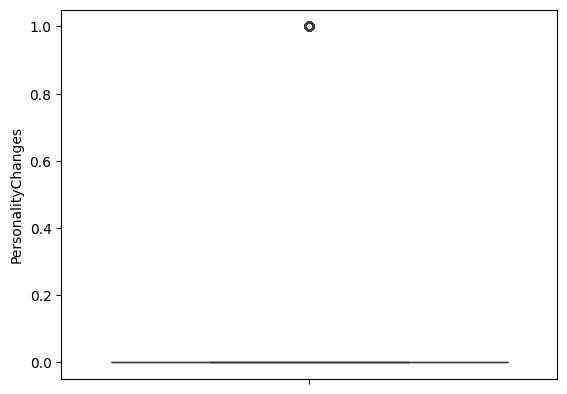

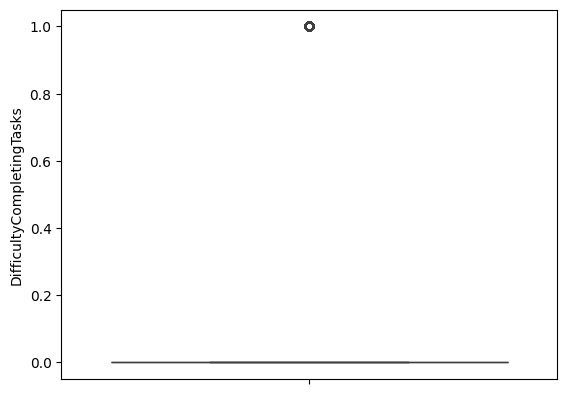

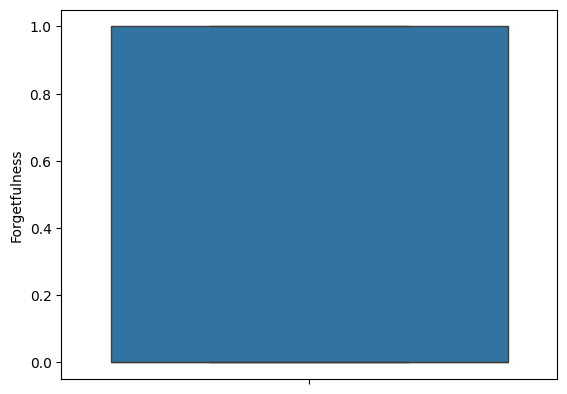

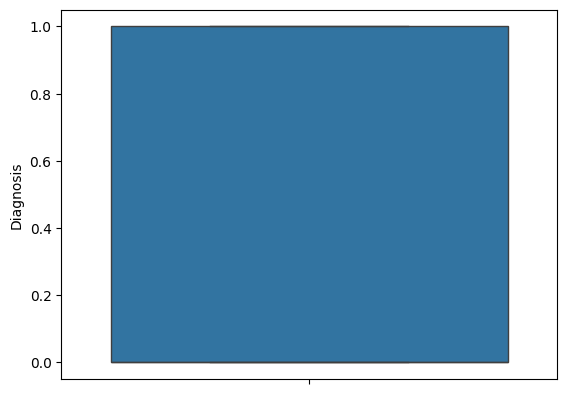

In [19]:
for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

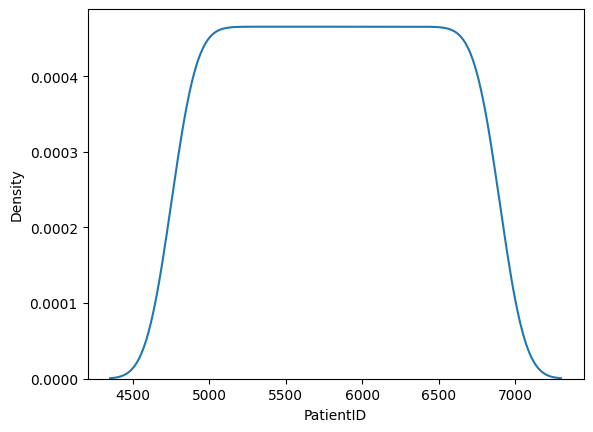

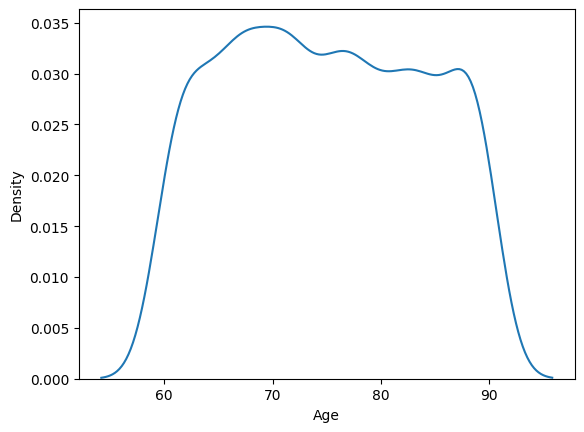

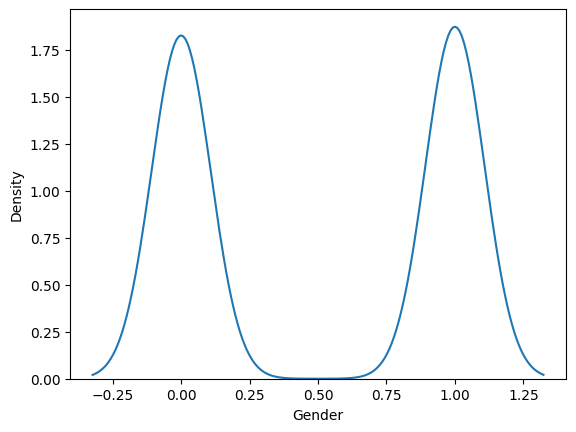

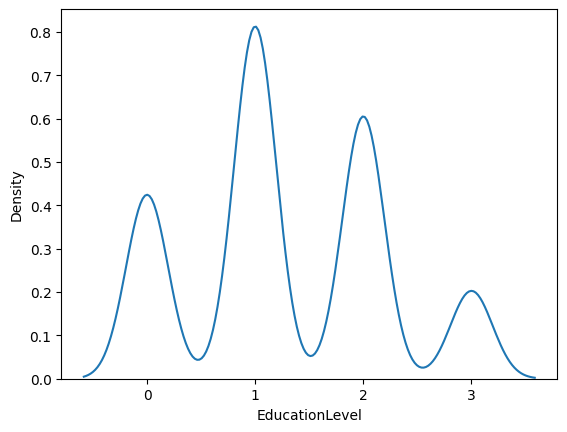

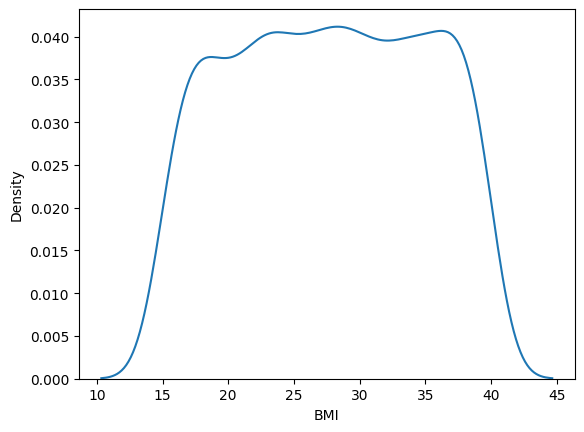

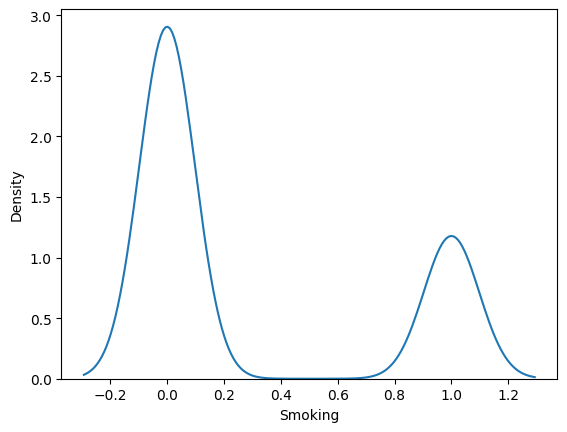

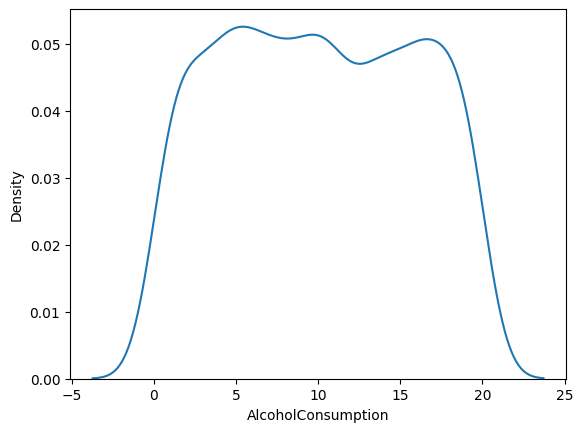

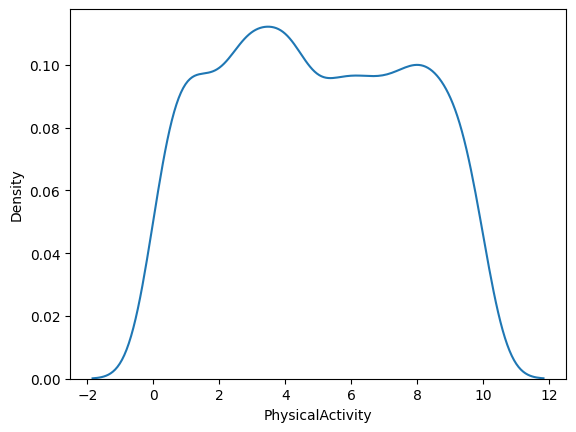

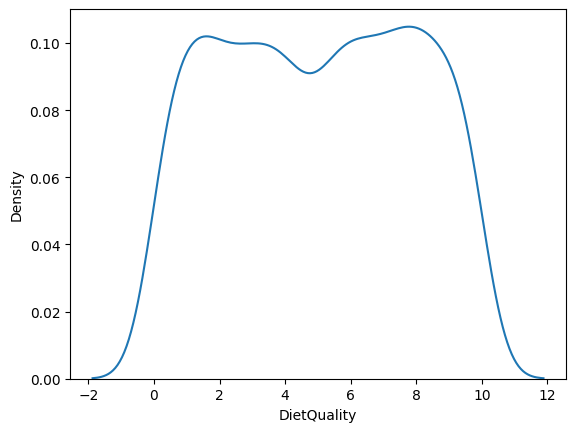

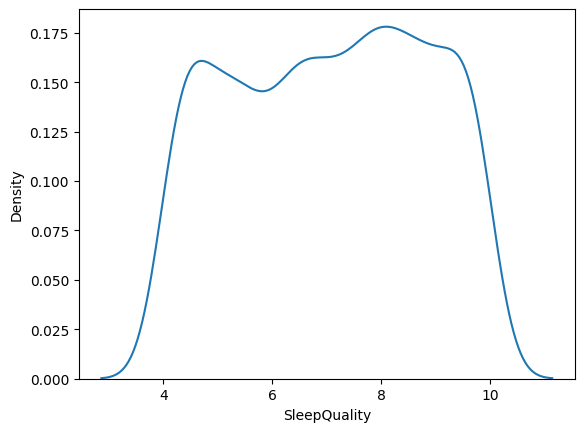

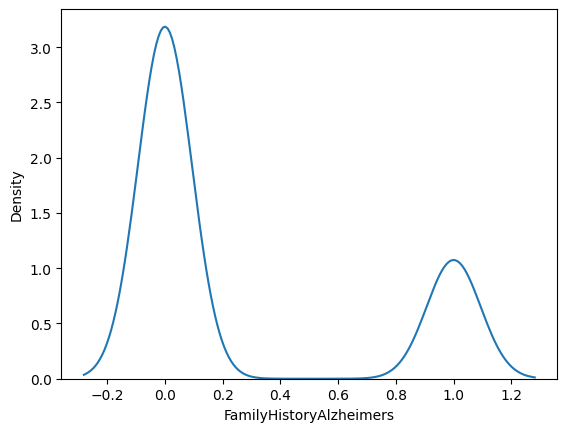

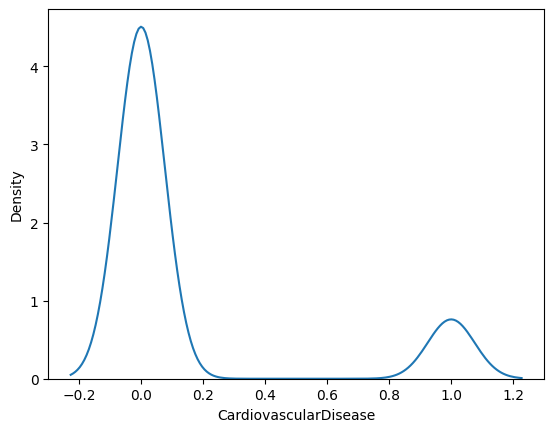

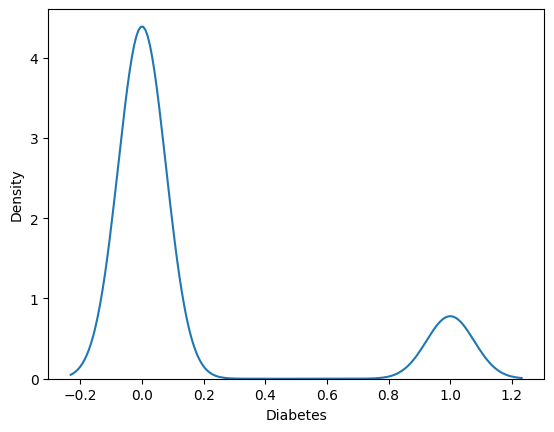

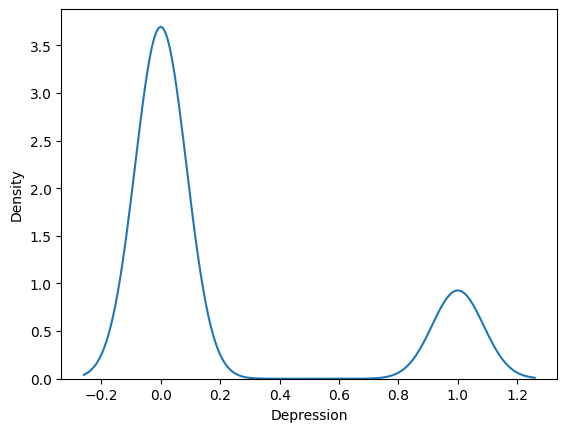

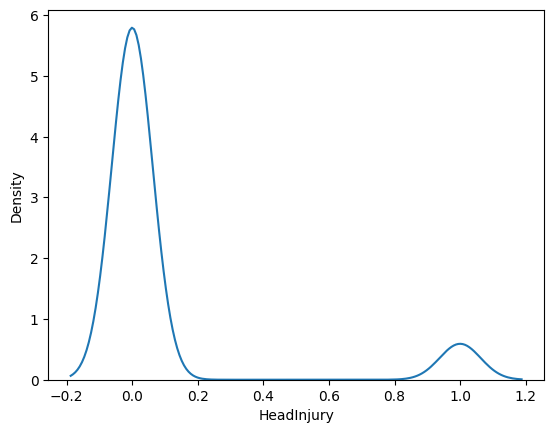

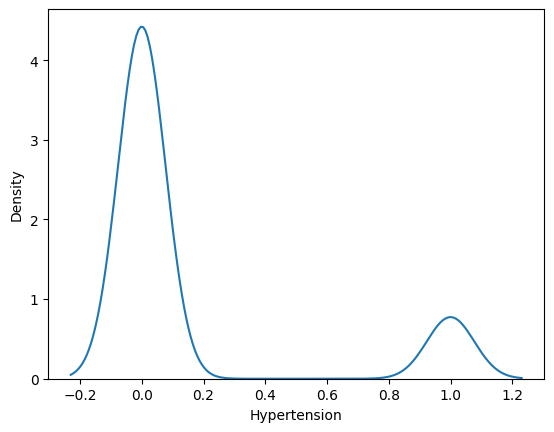

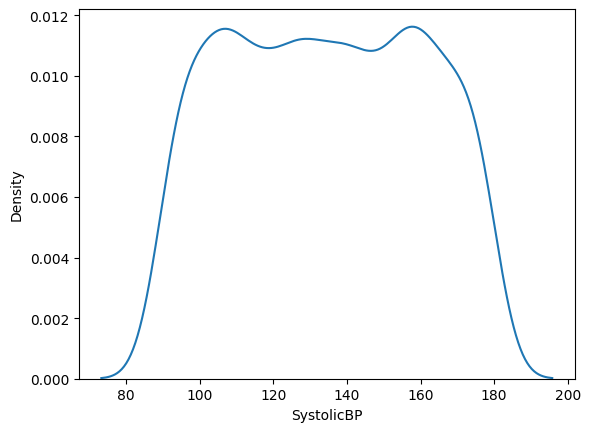

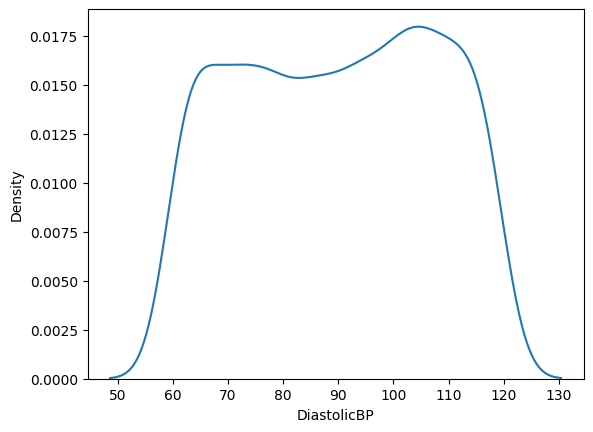

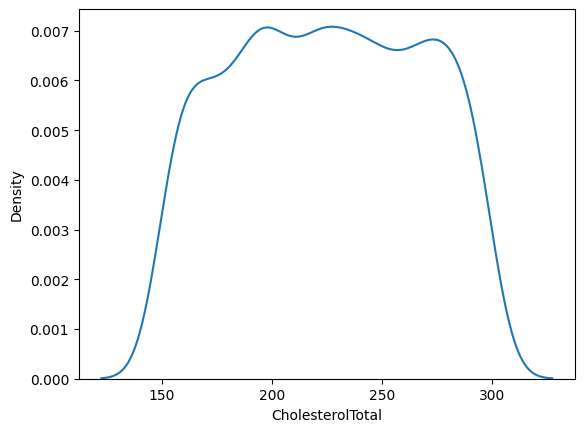

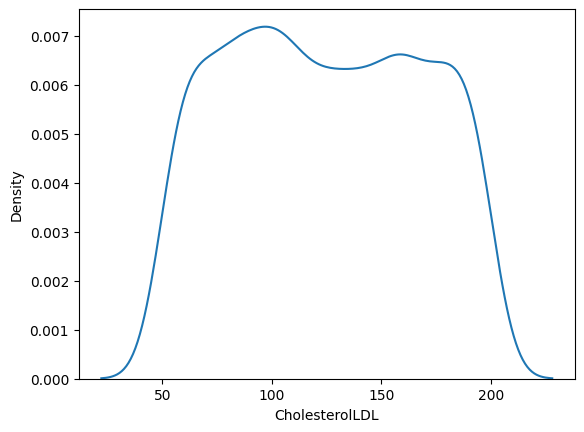

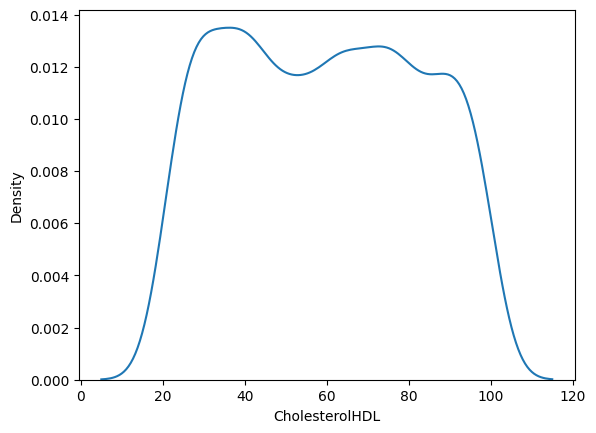

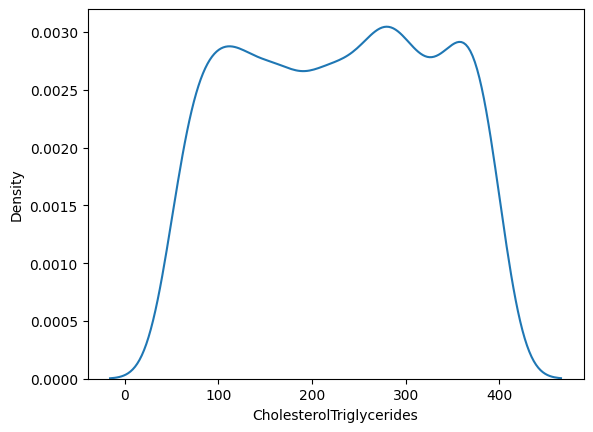

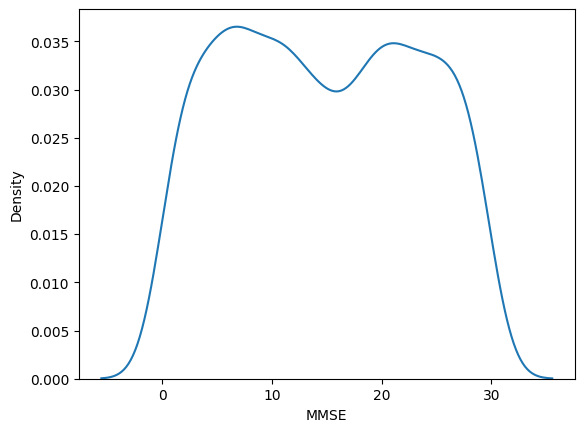

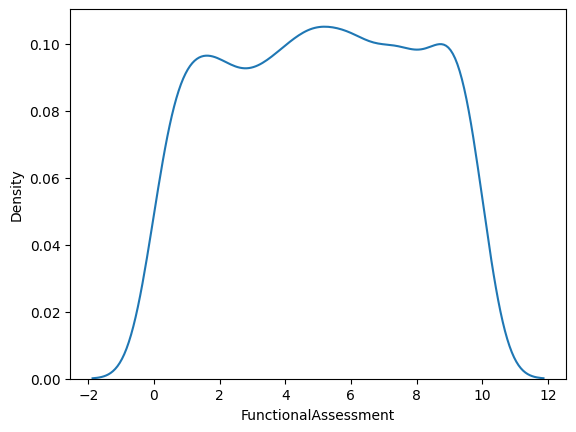

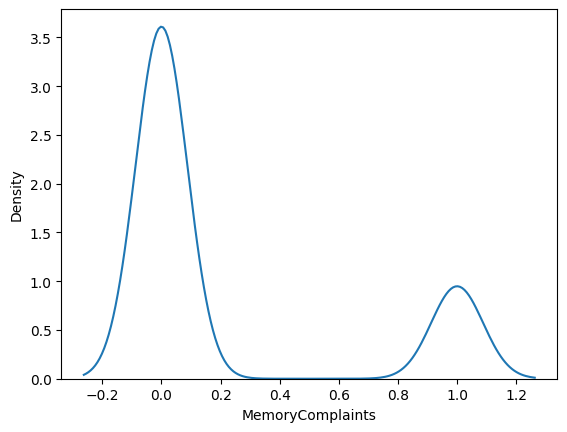

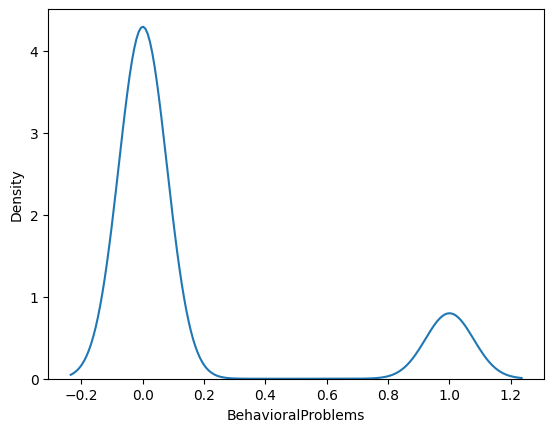

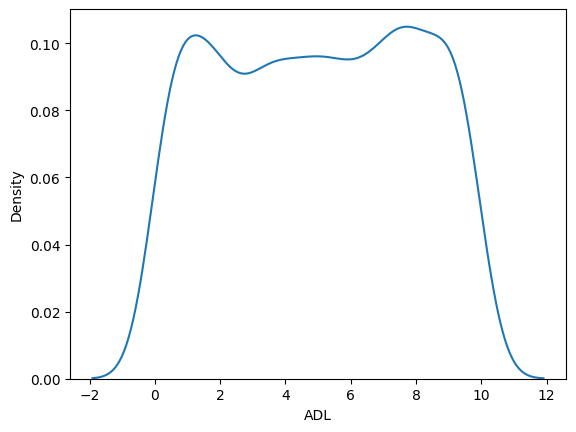

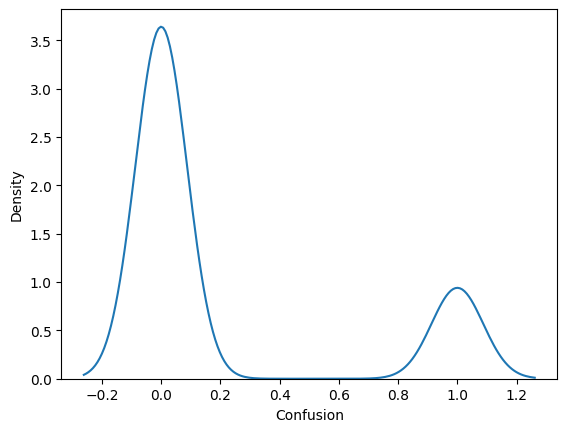

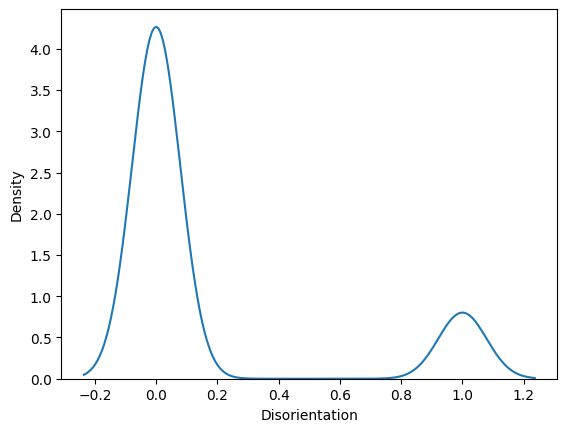

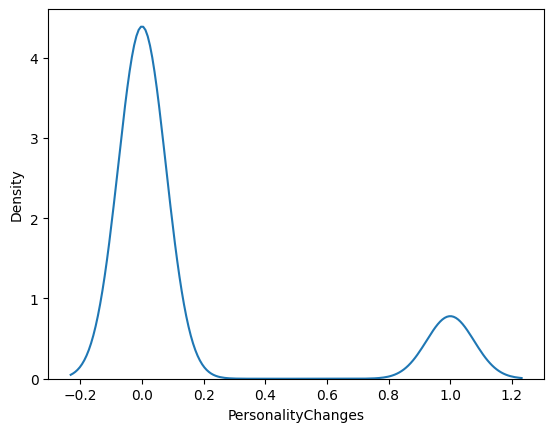

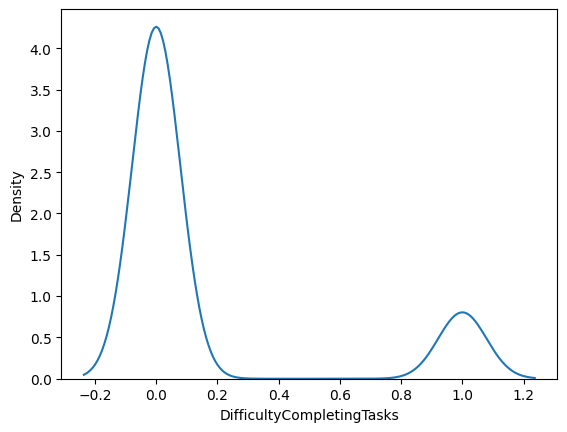

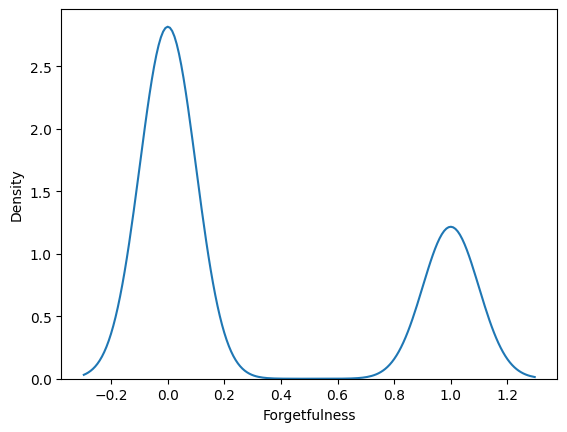

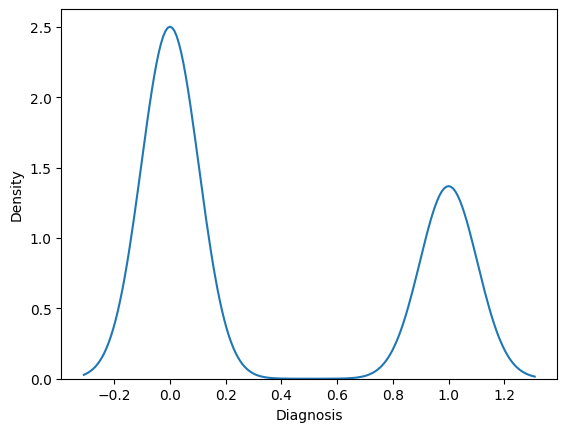

In [20]:
for col in df.columns:
    sns.kdeplot(df[col])
    plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , cross_val_score , learning_curve , GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , confusion_matrix
from sklearn.pipeline import Pipeline

In [22]:
X = df.drop(columns='Diagnosis')
y = df['Diagnosis']
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2, stratify=y , random_state=11)

In [23]:
lr_pipeline = Pipeline([
    ('scaler' ,StandardScaler()),
    ('classifier' ,LogisticRegression(max_iter=1000))

])
lr_pipeline.fit(X_train , y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [24]:
y_pred_lr = lr_pipeline.predict(X_test)
print(accuracy_score(y_test ,y_pred_lr))
print(confusion_matrix(y_test,y_pred_lr))

0.8
[[245  33]
 [ 53  99]]


In [25]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    ('scaler' ,StandardScaler()),
    ('classifier' ,RandomForestClassifier(random_state=11))

])
rf_pipeline.fit(X_train , y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [26]:
y_pred_rf = rf_pipeline.predict(X_test)
print(accuracy_score(y_test ,y_pred_rf))
print(confusion_matrix(y_test ,y_pred_rf))


0.9232558139534883
[[271   7]
 [ 26 126]]


In [29]:
from sklearn.svm import SVC
svm_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',SVC())
])

In [45]:

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__kernel': ['rbf', 'linear'],
    'classifier__gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001],
    'classifier__degree': [2, 3, 4]
}
grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

In [47]:
grid.fit(X_train,y_train)

Fitting 3 folds for each of 144 candidates, totalling 432 fits
[CV] END classifier__C=0.01, classifier__degree=2, classifier__gamma=scale, classifier__kernel=linear; total time=   0.1s
[CV] END classifier__C=0.01, classifier__degree=2, classifier__gamma=scale, classifier__kernel=linear; total time=   0.1s
[CV] END classifier__C=0.01, classifier__degree=2, classifier__gamma=scale, classifier__kernel=linear; total time=   0.1s
[CV] END classifier__C=0.01, classifier__degree=2, classifier__gamma=auto, classifier__kernel=rbf; total time=   0.2s
[CV] END classifier__C=0.01, classifier__degree=2, classifier__gamma=scale, classifier__kernel=rbf; total time=   0.2s
[CV] END classifier__C=0.01, classifier__degree=2, classifier__gamma=scale, classifier__kernel=rbf; total time=   0.2s
[CV] END classifier__C=0.01, classifier__degree=2, classifier__gamma=auto, classifier__kernel=rbf; total time=   0.2s
[CV] END classifier__C=0.01, classifier__degree=2, classifier__gamma=scale, classifier__kernel=rb

,estimator,Pipeline(step...amma=0.001))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__degree': [2, 3, ...], 'classifier__gamma': ['scale', 'auto', ...], 'classifier__kernel': ['rbf', 'linear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [49]:
y_pred_svm = grid.predict(X_test)
print(accuracy_score(y_test,y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

0.7976744186046512
[[243  35]
 [ 52 100]]


In [36]:
print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'classifier__C': 100, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'}
Best Accuracy: 0.8470150518679234


In [37]:
svm_pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('classifier',SVC(C = 100 ,gamma = 0.001 ,kernel = 'rbf'  ))

])
svm_pipeline.fit(X_train , y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,100
,kernel,'rbf'
,degree,3
,gamma,0.001


In [40]:
y_pred_svm_01 = svm_pipeline.predict(X_test)
print(accuracy_score(y_test,y_pred_svm_01))

0.8093023255813954


## Using Neural Network 

In [51]:
import torch 
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset , DataLoader
from sklearn.model_selection import ParameterGrid

In [53]:
scaler = StandardScaler()
X_train , X_val ,y_train ,y_val = train_test_split(X,y , test_size=0.2,random_state=42,stratify=y)

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
)


y_train = torch.tensor(
    y_train.values,
    dtype=torch.long
)

y_val = torch.tensor(
    y_val.values,
    dtype=torch.long
)
train_data = TensorDataset(X_train, y_train)
val_data = TensorDataset(X_val, y_val)


In [56]:
class NeuralNetwork(nn.Module):
    def __init__(self,input_size , hidden1, hidden2, dropout):
        super().__init__()

        self.model =nn.Sequential(
            nn.Linear(input_size,hidden1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden1),
            nn.Dropout(dropout),

            nn.Linear(hidden1,hidden2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden2),
            nn.Dropout(dropout),

            nn.Linear(hidden2, num_classes)
        )

    def forward(self,x):
        return self.model(x)
    


In [58]:
num_classes = len(np.unique(y))
input_size = X_train.shape[1]


In [59]:
params = {
    "hidden1": [64, 128, 256],
    "hidden2": [32, 64, 128],
    "dropout": [0.2, 0.3, 0.5],
    "lr": [0.01, 0.001],
    "batch_size": [16, 32, 64]
}

In [62]:
best_acc = 0
best_params = None

for p in ParameterGrid(params):

    train_loader = DataLoader(
        train_data,
        batch_size=p['batch_size'],
        shuffle=True
    )

    model = NeuralNetwork(
        input_size,
        p['hidden1'],
        p['hidden2'],
        p['dropout']
    )

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=p['lr']
    )

    # Training
    model.train()
    for epoch in range(50):
        for xb, yb in train_loader:

            optimizer.zero_grad()

            outputs = model(xb)

            loss = criterion(outputs, yb)

            loss.backward()

            optimizer.step()


    # Validation
    model.eval()

    with torch.no_grad():

        outputs = model(X_val)

        # Convert logits → class labels
        preds = torch.argmax(outputs, dim=1)

        # Convert tensors to numpy
        acc = accuracy_score(
            y_val.numpy(),
            preds.numpy()
        )

    print(
        "Parameters:", p,
        "Validation Accuracy:", acc
    )

    # Save best model
    if acc > best_acc:

        best_acc = acc
        best_params = p

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )


print("\nBest Accuracy:", best_acc)
print("Best Parameters:", best_params)

Parameters: {'batch_size': 16, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 32, 'lr': 0.01} Validation Accuracy: 0.8302325581395349
Parameters: {'batch_size': 16, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 32, 'lr': 0.001} Validation Accuracy: 0.8558139534883721
Parameters: {'batch_size': 16, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 64, 'lr': 0.01} Validation Accuracy: 0.858139534883721
Parameters: {'batch_size': 16, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 64, 'lr': 0.001} Validation Accuracy: 0.8441860465116279
Parameters: {'batch_size': 16, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 128, 'lr': 0.01} Validation Accuracy: 0.8534883720930233
Parameters: {'batch_size': 16, 'dropout': 0.2, 'hidden1': 64, 'hidden2': 128, 'lr': 0.001} Validation Accuracy: 0.8511627906976744
Parameters: {'batch_size': 16, 'dropout': 0.2, 'hidden1': 128, 'hidden2': 32, 'lr': 0.01} Validation Accuracy: 0.858139534883721
Parameters: {'batch_size': 16, 'dropout': 0.2, 'hidden1': 128, 'hidden2': 32, 'lr': 0.001} Va